# 1. Model Development Overview

**Project:** Predicting Rural Water Point Functionality Using Data Mining

**Target variable:** `functional3` (Functional / Partially functional / Abandoned or not functional)

**Task:** Multiclass classification

This notebook begins **Stage 6 — Model Development**. Data understanding, EDA and preprocessing have already been completed in notebooks 01–03. We compare the four algorithms in the proposal using baseline configurations, before hyperparameter optimization.

**Scope:** Decision Tree, Random Forest, KNN and SVM; training-only cross-validation and out-of-fold analysis. Hyperparameter tuning, class weights, resampling, feature changes, final model selection and system development are deferred. The final test set remains reserved.

**Source audit:** The supplied notebook 03 is the implementation authority. The older viva document describes different leakage removals, dropping `rehab_age`, mode imputation, `drop_first=True`, binary mappings and target label encoding. We preserve notebook 03 instead: seven leakage removals, retained rehabilitation age, explicit categorical missing values, full one-hot encoding, ordinal committee indices and text targets. These records predict current functionality; this experiment does not establish prediction of future failures.

# 2. Load Required Libraries

We use scikit-learn pipelines to fit preprocessing separately within each validation fold. The custom transformers and branch definitions below are copied from notebook 03 without changing their decisions. Versions are printed so the experiment can be reproduced.

In [27]:
from pathlib import Path
import hashlib
import json
import re
import platform
import warnings
from sklearn.exceptions import InconsistentVersionWarning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import joblib
from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer, precision_score

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "functional3"
CLASS_ORDER = ["Functional", "Partially functional", "Abandoned or not functional"]
# Find the project root from the kernel working directory. This supports
# launching from the project root, notebooks/, or another project subfolder.
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
     if (candidate / "data/raw/water_pump_functionality.xlsx").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root could not be found. Start the kernel inside the project "
        "containing data/raw/water_pump_functionality.xlsx. "
        f"Current working directory: {CURRENT_DIR}"
    )
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
print("Project root:", PROJECT_ROOT)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
print("Python:", platform.python_version(), "| sklearn:", sklearn.__version__, "| pandas:", pd.__version__)


Project root: E:\SLIIT\SLIIT Y3S2\FDM\fdm-water-point-functionality
Python: 3.11.9 | sklearn: 1.8.0 | pandas: 2.2.3


# 3. Load Prepared Data

The project root is detected from the kernel working directory and its parent folders. This supports launching from the project root or `notebooks/`. All paths follow the repository layout. The raw dataset and notebook 03 are required.

### Available project artifacts

The repository is audited at runtime for preprocessing artifacts. Existing artifacts are used only for consistency checks. Baseline model cross-validation reconstructs the exact preprocessing logic from notebook 03 so preprocessing can be fitted independently within each training fold. Missing optional files do not trigger placeholder creation or prevent model development.

The table and observations below describe the files present on the current run. Saved outputs describe that execution environment; rerun the notebook to audit a different checkout. Holdout files are inspected only for split consistency, shape and class distribution, never model performance.

In [28]:
raw_path = DATA_RAW / "water_pump_functionality.xlsx"
source03_path = PROJECT_ROOT / "notebooks" / "03_preprocessing.ipynb"
for path in [raw_path, source03_path]:
    assert path.is_file(), f"Required project source missing: {path}"
artifact_paths = {name: DATA_PROCESSED / name for name in [
    "X_train_processed.csv", "X_test_processed.csv", "y_train.csv", "y_test.csv", "feature_names.csv"
]}
artifact_paths["preprocessing_pipeline.joblib"] = MODELS_DIR / "preprocessing_pipeline.joblib"
artifact_paths["preprocessing_decisions.md"] = REPORTS_DIR / "preprocessing_decisions.md"
purposes = {
    "X_train_processed.csv": "Compare reconstructed training values and schema",
    "X_test_processed.csv": "Verify holdout shape/schema only; no model evaluation",
    "y_train.csv": "Verify original training label order",
    "y_test.csv": "Verify reserved holdout split; no model evaluation",
    "feature_names.csv": "Compare reconstructed feature names",
    "preprocessing_pipeline.joblib": "Optional train-only parity check if version-compatible",
    "preprocessing_decisions.md": "Read the existing decision record; preserve notebook 03 logic",
}
artifact_audit = pd.DataFrame([
    {"Artifact": name, "Path": path.relative_to(PROJECT_ROOT).as_posix(),
     "Exists": path.exists(), "Purpose": purposes[name]}
    for name, path in artifact_paths.items()
])
display(artifact_audit)
existing_artifacts = artifact_audit.loc[artifact_audit["Exists"], "Artifact"].tolist()
missing_artifacts = artifact_audit.loc[~artifact_audit["Exists"], "Artifact"].tolist()
display(Markdown("**Observation:** "
    + ("Present: " + ", ".join(existing_artifacts) + ". " if existing_artifacts else "None of the optional audit files is present. ")
    + ("Missing: " + ", ".join(missing_artifacts) + ". Saved contents of these files cannot be verified." if missing_artifacts else
       "All listed optional audit files are present; the following checks assess their contents.")))

# Inventory real contents, including unexpected files, without writing anything.
for folder in [DATA_PROCESSED, MODELS_DIR, REPORTS_DIR]:
    contents = sorted(path.relative_to(PROJECT_ROOT).as_posix()
                      for path in folder.rglob("*") if path.is_file()) if folder.is_dir() else []
    print(folder.relative_to(PROJECT_ROOT).as_posix() + ":", contents or "No files present")

requirements_path = PROJECT_ROOT / "requirements.txt"
requirements_text = requirements_path.read_text() if requirements_path.is_file() else None
if requirements_text is None:
    print("requirements.txt is absent; no project dependency constraint can be verified.")
else:
    sklearn_requirements = [line.strip() for line in requirements_text.splitlines()
                            if re.match(r"\s*scikit[-_]learn\b", line, flags=re.I)]
    print("requirements.txt scikit-learn declarations:", sklearn_requirements or "No direct constraint found")
print("Runtime scikit-learn version:", sklearn.__version__)
if artifact_paths["preprocessing_decisions.md"].is_file():
    preprocessing_decisions = artifact_paths["preprocessing_decisions.md"].read_text()
    print("Existing decision report read for context. Notebook 03 remains the implementation authority.")

# Hash every existing file under these folders, not only the expected artifacts.
protected_paths = set()
for folder in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, REPORTS_DIR]:
    if folder.is_dir():
        protected_paths.update(path for path in folder.rglob("*") if path.is_file())
protected_paths.update(PROJECT_ROOT.joinpath("notebooks").glob("0[123]*.ipynb"))
if requirements_path.is_file():
    protected_paths.add(requirements_path)
def file_hash(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()
protected_hashes = {path: file_hash(path) for path in protected_paths}
df = pd.read_excel(raw_path)
source03 = json.loads(source03_path.read_text(encoding="utf-8"))
assert TARGET in df.columns and not df[TARGET].isna().any()
assert set(df[TARGET]) == set(CLASS_ORDER)
assert df["id"].is_unique, "Unique source IDs are needed for the overlap audit."
print("Raw dataset shape:", df.shape)


,Artifact,Path,Exists,Purpose
0,X_train_processed.csv,data/processed/X_train_processed.csv,True,Compare reconstructed training values and schema
1,X_test_processed.csv,data/processed/X_test_processed.csv,True,Verify holdout shape/schema only; no model evaluation
2,y_train.csv,data/processed/y_train.csv,True,Verify original training label order
3,y_test.csv,data/processed/y_test.csv,True,Verify reserved holdout split; no model evaluation
4,feature_names.csv,data/processed/feature_names.csv,True,Compare reconstructed feature names
5,preprocessing_pipeline.joblib,models/preprocessing_pipeline.joblib,True,Optional train-only parity check if version-compatible
6,preprocessing_decisions.md,reports/preprocessing_decisions.md,True,Read the existing decision record; preserve notebook 03 logic


**Observation:** Present: X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv, feature_names.csv, preprocessing_pipeline.joblib, preprocessing_decisions.md. All listed optional audit files are present; the following checks assess their contents.

data/processed: ['data/processed/.gitkeep', 'data/processed/X_test_processed.csv', 'data/processed/X_train_processed.csv', 'data/processed/feature_names.csv', 'data/processed/y_test.csv', 'data/processed/y_train.csv']
models: ['models/.gitkeep', 'models/preprocessing_pipeline.joblib']
reports: ['reports/figures/.gitkeep', 'reports/preprocessing_decisions.md']
requirements.txt scikit-learn declarations: ['scikit-learn==1.8.0']
Runtime scikit-learn version: 1.8.0
Existing decision report read for context. Notebook 03 remains the implementation authority.
Raw dataset shape: (1793, 52)


## Fixed exclusions and split reconstruction

The following fixed removal list is copied from notebook 03. None of the excluded target symptoms, identifiers or pending-investigation columns is reintroduced. The original stratified 80/20 split uses seed 42. Source row indices and IDs allow us to check that the reconstructed training and holdout rows do not overlap.

In [29]:
LEAKAGE_COLS = [
    "wateravailable",
    "whynowatertoday_wp",
    "whynowatertoday_wp_other",
    "downtime2weeks",
    "minutesfill20l",
    "brokendays_wp",
    "qtymonthsnowater_wp",
]

IDENTIFIER_ADMIN_COLS = [
    "id",
    "instance_wp",
    "photo_wp",
    "commid_wp",
    "cwid",
    "timepoint_wp",
    "dataorg_wp",
    "subdate_wp",
    "admin2",
    "admin3",
]

PENDING_INVESTIGATION_COLS = [
    "grant_number_wp",
    "balance_any_dollars_wp",
]

DROP_COLS = LEAKAGE_COLS + IDENTIFIER_ADMIN_COLS + PENDING_INVESTIGATION_COLS
assert len(DROP_COLS) == len(set(DROP_COLS)), "Duplicate column in drop list"

missing_from_df = [c for c in DROP_COLS if c not in df.columns]
assert not missing_from_df, f"Expected columns not found in raw data: {missing_from_df}"

y = df[TARGET].copy()
X = df.drop(columns=[TARGET] + DROP_COLS).copy()

print(f"Leakage columns removed: {len(LEAKAGE_COLS)}")
print(f"Identifier/administrative columns removed: {len(IDENTIFIER_ADMIN_COLS)}")
print(f"Pending-investigation columns removed: {len(PENDING_INVESTIGATION_COLS)}")
print(f"Total columns removed (excluding target): {len(DROP_COLS)}")
print(f"X shape after removal: {X.shape}")

assert TARGET not in X.columns
assert all(c not in X.columns for c in DROP_COLS)
print("\nVerified: target and all excluded columns are absent from X.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
assert X_train.shape[0] + X_test.shape[0] == X.shape[0]
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]
assert set(X_train.index).isdisjoint(X_test.index)
assert set(df.loc[X_train.index, "id"]).isdisjoint(df.loc[X_test.index, "id"])
for name, labels in [("y_train.csv", y_train), ("y_test.csv", y_test)]:
    if artifact_paths[name].is_file():
        saved_labels = pd.read_csv(artifact_paths[name])
        assert saved_labels.columns.tolist() == [TARGET]
        pd.testing.assert_series_equal(labels.reset_index(drop=True), saved_labels[TARGET], check_names=False)
        print(name, "label order matches the reconstructed split.")
    else:
        print(name, "absent: exact saved-label correspondence cannot be verified.")
print("Expected raw predictor columns:")
display(pd.DataFrame({"Predictor": X_train.columns}))


Leakage columns removed: 7
Identifier/administrative columns removed: 10
Pending-investigation columns removed: 2
Total columns removed (excluding target): 19
X shape after removal: (1793, 32)

Verified: target and all excluded columns are absent from X.
X_train: (1434, 32), X_test: (359, 32)
y_train: (1434,), y_test: (359,)
y_train.csv label order matches the reconstructed split.
y_test.csv label order matches the reconstructed split.
Expected raw predictor columns:


,Predictor
0,country
1,admin1
2,latitude_wp
3,longitude_wp
4,elevation_wp
5,cwfunded_wp
6,wptype
7,pumptype
8,drillmethod
9,piped_source


## Reuse the exact preprocessing implementation

We retain the deterministic savings cleanup, quantile-based age groups, guarded household ratio, rehabilitation flags and management flag. Missing-value treatment, rare grouping (`min_frequency=10`), ordinal mapping, log transforms and scaling are unchanged. The custom definitions remain in this notebook, so no support module is needed.

Notebook 03 applies savings-sentinel cleanup **outside** its saved pipeline. We wrap that same fixed function in a `FunctionTransformer` here, followed by the unchanged pipeline. This preserves the calculations and ensures every modelling call receives cleaned inputs. No source notebook or saved pipeline is changed.

In [30]:
SENTINEL_MAP = {999.0: np.nan, 888.0: np.nan}

def clean_wc_savings(X):
    # Recode wc_savings_wp survey sentinel codes (999, 888) to missing.
    X = X.copy()
    X["wc_savings_wp"] = X["wc_savings_wp"].replace(SENTINEL_MAP)
    return X

X_train = clean_wc_savings(X_train)

X_test = clean_wc_savings(X_test)

class FeatureEngineer(BaseEstimator, TransformerMixin):
    # Adds engineered features. All fitted statistics come from the data passed
    # to .fit() only (i.e. the training split, when used inside the full pipeline).

    def fit(self, X, y=None):
        wp_age_train = X["wp_age"].astype(float)
        self.wp_age_median_ = wp_age_train.median()
        wp_age_filled = wp_age_train.fillna(self.wp_age_median_)
        q1, q2 = wp_age_filled.quantile([1 / 3, 2 / 3])
        self.wp_age_edges_ = (float(q1), float(q2))
        return self

    def transform(self, X):
        X = X.copy()

        # people_per_household: guard against division by zero / missing inputs
        qtyhh_safe = X["qtyhh_wp"].replace(0, np.nan)
        X["people_per_household"] = X["qtypeople_wp"] / qtyhh_safe

        # was_rehabilitated: clean 0/1/NaN mirror of rehabyn
        X["was_rehabilitated"] = X["rehabyn"].map({"Yes": 1, "No": 0})

        # has_management_committee: Water committee vs. everything else
        X["has_management_committee"] = (X["whomanage_wp"] == "Water committee").astype(int)

        # rehab_age: preserve structural meaning (fill 0 + explicit indicator)
        X["rehab_age_missing"] = X["rehab_age"].isna().astype(int)
        X["rehab_age"] = X["rehab_age"].fillna(0)

        # pop_1000: separate missing-indicator (kept apart from the log1p branch)
        X["pop_1000_missing"] = X["pop_1000"].isna().astype(int)

        # wp_age_group: bin using edges fitted on the training split only
        wp_age_filled = X["wp_age"].fillna(self.wp_age_median_)
        q1, q2 = self.wp_age_edges_
        X["wp_age_group"] = pd.cut(
            wp_age_filled,
            bins=[-np.inf, q1, q2, np.inf],
            labels=["New", "Established", "Old"],
        ).astype(str)

        return X

_fe_preview = FeatureEngineer().fit(X_train)

_preview_out = _fe_preview.transform(X_train.head())

In [31]:
CAT_NOT_APPLICABLE_COLS = ["pumptype", "drillmethod", "piped_source", "piped_pump"]

CAT_UNKNOWN_COLS = [
    "country", "admin1", "wptype", "whomanage_wp", "rehabyn", "season",
    "cwfunded_wp", "wc_present_wp", "paytocollect_wp", "lockedfullday_wp",
    "wp_age_group",
]

ORDINAL_COLS = [
    "wc_admin_index_wp", "wc_finance_index_wp", "wc_mgmt_index_wp", "wc_maint_index_wp",
]

RARE_CATEGORY_MIN_FREQUENCY = 10

cat_not_applicable_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Not applicable")),
    ("onehot", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=RARE_CATEGORY_MIN_FREQUENCY,
        sparse_output=False,
    )),
])

cat_unknown_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=RARE_CATEGORY_MIN_FREQUENCY,
        sparse_output=False,
    )),
])

ORDINAL_CATEGORY_ORDER = ["Inadequate", "Minimum", "Moderate", "Advanced", "Missing"]

ORDINAL_MISSING_RAW_CODE = len(ORDINAL_CATEGORY_ORDER) - 1

def remap_ordinal_missing_code(codes):
    # Sends the raw "Missing" category code (4) to -1; leaves 0-3 untouched.
    return np.where(codes == ORDINAL_MISSING_RAW_CODE, -1, codes)

ordinal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("ordinal", OrdinalEncoder(categories=[ORDINAL_CATEGORY_ORDER] * len(ORDINAL_COLS))),
    ("remap_missing", FunctionTransformer(remap_ordinal_missing_code, feature_names_out="one-to-one")),
])

NUM_LOG_SCALE_COLS = ["wp_age", "qtypeople_wp", "qtyhh_wp", "pop_1000"]

NUM_SCALE_NOINDICATOR_COLS = ["elevation_wp", "latitude_wp", "longitude_wp", "rehab_age"]

NUM_SCALE_INDICATOR_COLS = [
    "annual_rain", "wpqty_wp", "qtyhh_c_wp", "improved_wponly_wp",
    "wc_savings_wp", "pumpstrokes", "people_per_household", "was_rehabilitated",
]

PASSTHROUGH_COLS = ["rehab_age_missing", "pop_1000_missing", "has_management_committee"]

log_scale_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", StandardScaler()),
])

scale_noindicator_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

scale_indicator_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median", add_indicator=True)),
    ("scale", StandardScaler()),
])

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat_not_applicable", cat_not_applicable_pipe, CAT_NOT_APPLICABLE_COLS),
        ("cat_unknown", cat_unknown_pipe, CAT_UNKNOWN_COLS),
        ("ordinal_wc_index", ordinal_pipe, ORDINAL_COLS),
        ("num_log_scale", log_scale_pipe, NUM_LOG_SCALE_COLS),
        ("num_scale_noindicator", scale_noindicator_pipe, NUM_SCALE_NOINDICATOR_COLS),
        ("num_scale_indicator", scale_indicator_pipe, NUM_SCALE_INDICATOR_COLS),
        ("passthrough_flags", "passthrough", PASSTHROUGH_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)
preprocessor.set_output(transform="pandas")

full_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessing", preprocessor),
])

full_pipeline
# Fixed cleanup + the exact, initially unfitted two-step pipeline from notebook 03.
fold_preprocessing = Pipeline([
    ("fixed_cleanup", FunctionTransformer(clean_wc_savings)),
    ("prepared_features", clone(full_pipeline)),
])
print("Pipeline:", fold_preprocessing)


Pipeline: Pipeline(steps=[('fixed_cleanup',
                 FunctionTransformer(func=<function clean_wc_savings at 0x000001D22AAA9440>)),
                ('prepared_features',
                 Pipeline(steps=[('feature_engineering', FeatureEngineer()),
                                 ('preprocessing',
                                  ColumnTransformer(transformers=[('cat_not_applicable',
                                                                   Pipeline(steps=[('impute',
                                                                                    SimpleImputer(fill_value='Not '
                                                                                                             'applicable',
                                                                                                  strategy='constant')),
                                                                                   ('...
                                                               

## Training-only reference checks

An independent clone is fitted on the full training portion **only to audit the reference feature schema**. This fitted clone is never used for validation. Every CV call below starts from an unfitted clone instead.

The reference feature names recorded in notebook 03 provide a check when the CSVs are missing. Recorded notebook output is weaker evidence than the actual artifact bytes; we explicitly distinguish these checks. We do not transform the raw holdout in this notebook.

A saved joblib pipeline is checked only if present and compatible with the current scikit-learn version. A version mismatch is reported explicitly and the optional comparison is skipped; the mismatched object is not used in modelling. No dependency pin or artifact is changed automatically.

In [33]:
reference_pipeline = clone(fold_preprocessing)
training_reference = reference_pipeline.fit_transform(X_train, y_train)
assert np.isfinite(training_reference.to_numpy()).all()
feature_names = training_reference.columns.tolist()

# Read recorded output by content, rather than relying on cell positions.
recorded_text = "\n".join(
    "".join(output.get("text", []))
    for cell in source03["cells"] for output in cell.get("outputs", [])
)
recorded_names = re.findall(r"^\s*\d+\. ((?:cat_|ordinal_|num_|passthrough_).+)$", recorded_text, flags=re.M)
if recorded_names:
    assert feature_names == recorded_names, "Reconstructed schema differs from notebook 03's recorded output."
    print("Feature names exactly match notebook 03's recorded feature list.")

saved_train = saved_test = None
if artifact_paths["X_train_processed.csv"].is_file():
    saved_train = pd.read_csv(artifact_paths["X_train_processed.csv"])
    assert saved_train.columns.tolist() == feature_names
    assert saved_train.shape == training_reference.shape
    np.testing.assert_allclose(saved_train.to_numpy(), training_reference.to_numpy(), rtol=1e-8, atol=1e-10)
    print("Processed training CSV matches reconstructed training values.")
else:
    print("X_train_processed.csv is absent; saved training values could not be compared.")
if artifact_paths["X_test_processed.csv"].is_file():
    saved_test = pd.read_csv(artifact_paths["X_test_processed.csv"])
    assert saved_test.shape == (len(y_test), len(feature_names))
    assert saved_test.columns.tolist() == feature_names
    print("Processed holdout CSV shape/schema checked only:", saved_test.shape)
else:
    print("X_test_processed.csv was not present; its saved contents could not be independently compared.")
if artifact_paths["feature_names.csv"].is_file():
    assert pd.read_csv(artifact_paths["feature_names.csv"])["feature_name"].tolist() == feature_names
    print("feature_names.csv matches reconstructed feature names.")
else:
    print("feature_names.csv is absent; no saved feature-name file was validated.")

pipeline_verification = "Not performed: no serialized preprocessing pipeline is present in models/."
if artifact_paths["preprocessing_pipeline.joblib"].is_file():
    # A serialized estimator from another sklearn version is optional evidence,
    # not an input to CV. Do not suppress a mismatch and continue using that object.
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("error", InconsistentVersionWarning)
            saved_pipeline = joblib.load(artifact_paths["preprocessing_pipeline.joblib"])
    except InconsistentVersionWarning as version_warning:
        pipeline_verification = (
            "Skipped saved-pipeline verification: artifact sklearn version "
            f"{version_warning.original_sklearn_version} differs from runtime "
            f"{version_warning.current_sklearn_version}. Use one compatible sklearn version "
            "across notebook 03, modelling, optimization and eventual backend use. "
            "CV continues with the exact reconstructed preprocessing; no artifact was regenerated."
        )
    else:
        loaded_train = saved_pipeline.transform(clean_wc_savings(X_train))
        assert loaded_train.columns.tolist() == feature_names
        np.testing.assert_allclose(loaded_train.to_numpy(), training_reference.to_numpy(), rtol=1e-8, atol=1e-10)
        pipeline_verification = "PASS: saved pipeline reproduces reconstructed training output."
        del saved_pipeline
print(pipeline_verification)

fe = reference_pipeline.named_steps["prepared_features"].named_steps["feature_engineering"]
assert np.isclose(fe.wp_age_median_, X_train["wp_age"].median())
expected_edges = X_train["wp_age"].fillna(X_train["wp_age"].median()).quantile([1/3, 2/3]).to_numpy()
np.testing.assert_allclose(fe.wp_age_edges_, expected_edges)
print("Train-only age bin edges:", fe.wp_age_edges_)
print("Reconstructed processed training shape:", training_reference.shape)
print("Expected holdout schema (not transformed):", (len(y_test), len(feature_names)))
# Release the fitted audit object: it is not an input to any model experiment.
del reference_pipeline, fe


Feature names exactly match notebook 03's recorded feature list.
Processed training CSV matches reconstructed training values.
Processed holdout CSV shape/schema checked only: (359, 110)
feature_names.csv matches reconstructed feature names.
Skipped saved-pipeline verification: artifact sklearn version 1.9.1 differs from runtime 1.8.0. Use one compatible sklearn version across notebook 03, modelling, optimization and eventual backend use. CV continues with the exact reconstructed preprocessing; no artifact was regenerated.
Train-only age bin edges: (2.0, 4.0)
Reconstructed processed training shape: (1434, 110)
Expected holdout schema (not transformed): (359, 110)


**Observation:** The checks distinguish available artifact contents from in-memory reconstruction and recorded source output. The full-training processed matrix is a reference only; using it directly in CV would allow validation rows to influence preprocessing statistics. The modelling inputs below are the raw training predictors.

# 4. Verify Training and Holdout Data

Stratification preserves approximately the same proportion of each class in both splits. This helps ensure the smallest class is represented rather than left largely in one split. We display counts and percentages for verification, without assessing model performance on holdout labels.

**The test set will not be used for model selection in this notebook.**

In [34]:
class_distribution = pd.DataFrame({
    "Training count": y_train.value_counts().reindex(CLASS_ORDER),
    "Training %": y_train.value_counts(normalize=True).reindex(CLASS_ORDER) * 100,
    "Holdout count": y_test.value_counts().reindex(CLASS_ORDER),
    "Holdout %": y_test.value_counts(normalize=True).reindex(CLASS_ORDER) * 100,
})
display(class_distribution.round(2))
display(pd.DataFrame([
    ["Raw training predictors", X_train.shape, "Reconstructed split"],
    ["Raw holdout predictors", X_test.shape, "Reconstructed split; reserved"],
    ["Processed training reference", training_reference.shape, "Reconstructed; CSV checked if present"],
    ["Processed holdout", saved_test.shape if saved_test is not None else (len(y_test), len(feature_names)),
     "CSV shape verified" if saved_test is not None else "Expected schema only; CSV absent"],
], columns=["Data", "Shape", "Evidence"]))
assert len(X_train) == len(y_train) and len(X_test) == len(y_test)
assert set(y_train) == set(y_test) == set(CLASS_ORDER)
assert (class_distribution["Training count"] >= 5).all()
# Separate modelling inputs explicitly. No evaluation function receives holdout data.
X_development, y_development = X_train.copy(), y_train.copy()
assert X_development.index.equals(y_development.index)
assert set(X_development.index).isdisjoint(X_test.index)


,Training count,Training %,Holdout count,Holdout %
functional3,,,,
Functional,1066,74.34,267,74.37
Partially functional,126,8.79,31,8.64
Abandoned or not functional,242,16.88,61,16.99


,Data,Shape,Evidence
0,Raw training predictors,"(1434, 32)",Reconstructed split
1,Raw holdout predictors,"(359, 32)",Reconstructed split; reserved
2,Processed training reference,"(1434, 110)",Reconstructed; CSV checked if present
3,Processed holdout,"(359, 110)",CSV shape verified


**Observation:** The displayed class counts confirm whether stratification preserved the original imbalance. Stratification does not balance the classes; it keeps their representation consistent. The processed holdout shape is marked as an expected schema when its CSV is absent, rather than claimed as a verified artifact.

# 5. Evaluation Strategy

Accuracy gives more influence to the Functional majority because it counts correct predictions across all rows. **Macro-F1** computes each class's F1-score and gives the three classes equal weight. This makes poor minority-class performance visible. Minority recall measures how many actual problematic water points are identified; precision shows how reliable those predictions are.

We use **5-fold StratifiedKFold**, with shuffling and seed 42. Each training row is validated once, while the other four folds fit both preprocessing and the model. All algorithms use identical folds. Supporting metrics are accuracy, macro precision, macro recall and weighted F1; fit and scoring times are also recorded. Weighted F1 still reflects class prevalence and must be read alongside macro-F1.

Fold means summarize separate validation runs. Their standard deviations describe variability, not a formal significance test. Out-of-fold pooled reports later describe all training rows together and can differ slightly from fold-average metrics.

The random split estimates performance on similar sampled records. It does not establish transfer to unseen countries or future survey waves; geography remains a documented limitation of the existing design.

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_folds = list(cv.split(X_development, y_development))
validation_visits = np.zeros(len(y_development), dtype=int)
fold_rows = []
for fold, (train_idx, valid_idx) in enumerate(cv_folds, start=1):
    assert set(train_idx).isdisjoint(valid_idx)
    validation_visits[valid_idx] += 1
    fold_rows.append({"Fold": fold, "Fit rows": len(train_idx), "Validation rows": len(valid_idx),
                      **y_development.iloc[valid_idx].value_counts().reindex(CLASS_ORDER).to_dict()})
assert (validation_visits == 1).all()
display(pd.DataFrame(fold_rows))
scoring = {
    "accuracy": "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}
# zero_division=0 reports zero precision when a class receives no predictions.
# It changes reporting behaviour, not the learned model or class weighting.


,Fold,Fit rows,Validation rows,Functional,Partially functional,Abandoned or not functional
0,1,1147,287,214,25,48
1,2,1147,287,213,26,48
2,3,1147,287,213,25,49
3,4,1147,287,213,25,49
4,5,1148,286,213,25,48


**Observation:** Every training row appears in one validation fold, and all three classes occur in each fold. The fold sizes and class counts above make the shared validation design reviewable.

# 6. Define Baseline Models

A baseline is the starting configuration used before searching for better parameters. We use library defaults and seed 42 where supported. No class weighting, resampling or tuning is applied.

| Algorithm | Reason for inclusion |
|---|---|
| Decision Tree | Interpretable nonlinear classifier that can capture feature interactions. |
| Random Forest | Tree ensemble that offers a comparison with a single tree. |
| KNN | Distance-based method; the existing scaled numeric features make this a useful comparison. |
| SVM | Scale-sensitive nonlinear classifier suitable for this modest tabular dataset. |

Scaling, one-hot features and missing indicators affect distances, so KNN and SVM outcomes must be inspected rather than assumed to be strong. All models use the same preprocessing decisions.

In [36]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=RANDOM_STATE),
}
def modelling_pipeline(estimator):
    return Pipeline([("preprocessing", clone(fold_preprocessing)), ("model", clone(estimator))])
display(pd.DataFrame({"Model": models.keys(), "Baseline configuration": [str(m) for m in models.values()]}))


,Model,Baseline configuration
0,Decision Tree,DecisionTreeClassifier(random_state=42)
1,Random Forest,RandomForestClassifier(random_state=42)
2,KNN,KNeighborsClassifier()
3,SVM,SVC(random_state=42)


# 7. Cross-Validation Baseline Evaluation

Each estimator receives raw training rows inside a fresh preprocessing-plus-model pipeline. `cross_validate` clones this pipeline for each fold, so no fitted full-training transformer is reused. We keep all fold scores at full precision and round only the displayed comparison. Fit time includes preprocessing and model fitting; it is specific to the execution environment.

In [37]:
cv_results, result_rows = {}, []
for name, estimator in models.items():
    scores = cross_validate(
        modelling_pipeline(estimator), X_development, y_development,
        cv=cv_folds, scoring=scoring, n_jobs=1, error_score="raise", return_estimator=True,
    )
    # Audit actual fitted fold statistics, rather than only asserting the design.
    for fitted, (fit_idx, _) in zip(scores["estimator"], cv_folds):
        fold_input = X_development.iloc[fit_idx]
        fitted_features = fitted.named_steps["preprocessing"].named_steps["prepared_features"]
        fold_fe = fitted_features.named_steps["feature_engineering"]
        fold_age = fold_input["wp_age"]
        assert np.isclose(fold_fe.wp_age_median_, fold_age.median())
        np.testing.assert_allclose(fold_fe.wp_age_edges_, fold_age.fillna(fold_age.median()).quantile([1/3, 2/3]))
        fold_log = fold_input[NUM_LOG_SCALE_COLS].fillna(fold_input[NUM_LOG_SCALE_COLS].median())
        fitted_scaler = fitted_features.named_steps["preprocessing"].named_transformers_["num_log_scale"].named_steps["scale"]
        np.testing.assert_allclose(fitted_scaler.mean_, np.log1p(fold_log).mean().to_numpy())
    cv_results[name] = scores
    result_rows.append({
        "Model": name,
        "Mean CV Accuracy": scores["test_accuracy"].mean(),
        "Std CV Accuracy": scores["test_accuracy"].std(),
        "Mean CV Macro Precision": scores["test_precision_macro"].mean(),
        "Mean CV Macro Recall": scores["test_recall_macro"].mean(),
        "Mean CV Macro F1": scores["test_f1_macro"].mean(),
        "Std CV Macro F1": scores["test_f1_macro"].std(),
        "Mean CV Weighted F1": scores["test_f1_weighted"].mean(),
        "Mean Fit Time (s)": scores["fit_time"].mean(),
        "Mean Score Time (s)": scores["score_time"].mean(),
    })
results = pd.DataFrame(result_rows).set_index("Model").sort_values("Mean CV Macro F1", ascending=False)
assert set(results.index) == set(models) and len(results) == 4
assert np.isfinite(results.to_numpy()).all()
display(results.round(4))


,Mean CV Accuracy,Std CV Accuracy,Mean CV Macro Precision,Mean CV Macro Recall,Mean CV Macro F1,Std CV Macro F1,Mean CV Weighted F1,Mean Fit Time (s),Mean Score Time (s)
Model,,,,,,,,,
Random Forest,0.8459,0.0060,0.7308,0.6247,0.6542,0.0254,0.8293,0.3752,0.0571
Decision Tree,0.7950,0.0168,0.6276,0.6324,0.6289,0.0224,0.7983,0.1121,0.0458
KNN,0.7950,0.0139,0.6424,0.5190,0.5365,0.0226,0.7670,0.0737,0.0674
SVM,0.8257,0.0076,0.5469,0.5193,0.5239,0.0102,0.7810,0.1342,0.0685


In [38]:
display(Markdown("**Observation:** The highest observed baseline mean macro-F1 is "
    f"{results.iloc[0]['Mean CV Macro F1']:.4f} for **{results.index[0]}**. "
    "This is a training-CV ranking, not a final model choice. The standard deviations show how much scores vary across folds."))


**Observation:** The highest observed baseline mean macro-F1 is 0.6542 for **Random Forest**. This is a training-CV ranking, not a final model choice. The standard deviations show how much scores vary across folds.

# 8. Baseline Model Comparison

We plot macro-F1 with one-standard-deviation error bars and compare accuracy with macro-F1. A large gap between the metrics warrants examining per-class performance. Error bars describe fold variation; overlapping bars alone cannot establish whether models differ statistically.

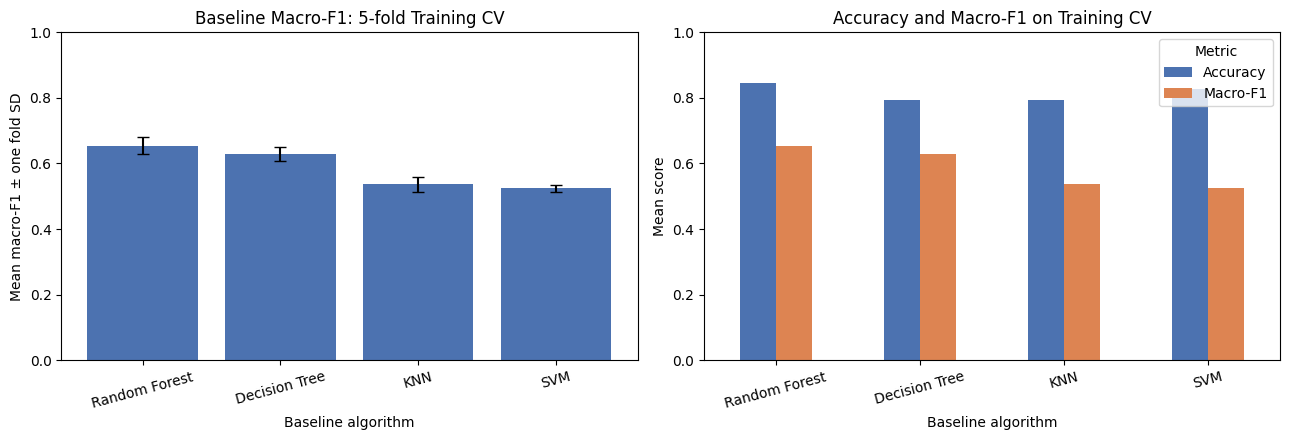

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(results.index, results["Mean CV Macro F1"], yerr=results["Std CV Macro F1"], capsize=4, color="#4C72B0")
axes[0].set_title("Baseline Macro-F1: 5-fold Training CV")
axes[0].set_ylabel("Mean macro-F1 ± one fold SD")
axes[0].set_xlabel("Baseline algorithm")
results[["Mean CV Accuracy", "Mean CV Macro F1"]].rename(columns={
    "Mean CV Accuracy": "Accuracy", "Mean CV Macro F1": "Macro-F1"
}).plot.bar(ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Accuracy and Macro-F1 on Training CV")
axes[1].set_ylabel("Mean score")
axes[1].set_xlabel("Baseline algorithm")
axes[1].legend(title="Metric")
for ax in axes:
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


In [40]:
largest_gap_model = (results["Mean CV Accuracy"] - results["Mean CV Macro F1"]).idxmax()
most_variable = results["Std CV Macro F1"].idxmax()
display(Markdown(
    f"**Observation:** **{largest_gap_model}** has the largest accuracy–macro-F1 gap "
    f"({results.loc[largest_gap_model, 'Mean CV Accuracy']:.4f} vs "
    f"{results.loc[largest_gap_model, 'Mean CV Macro F1']:.4f}). "
    "The per-class reports below check which classes contribute to this difference. "
    f"**{most_variable}** has the largest fold SD in macro-F1 "
    f"({results.loc[most_variable, 'Std CV Macro F1']:.4f}); "
    "these five folds do not provide enough evidence for a claim of statistical superiority."
))


**Observation:** **SVM** has the largest accuracy–macro-F1 gap (0.8257 vs 0.5239). The per-class reports below check which classes contribute to this difference. **Random Forest** has the largest fold SD in macro-F1 (0.0254); these five folds do not provide enough evidence for a claim of statistical superiority.

# 9. Out-of-Fold Predictions

For each baseline we generate one prediction per training row from a pipeline fitted on the other folds. These are held-out **training** predictions, not predictions from a model fitted on all training rows. We reuse exactly the same folds and configurations as the comparison above. This second CV pass supports readable classification reports and confusion matrices without accessing the final holdout.

In [41]:
oof_predictions = {}
for name, estimator in models.items():
    predictions = cross_val_predict(
        modelling_pipeline(estimator), X_development, y_development,
        cv=cv_folds, method="predict", n_jobs=1,
    )
    assert len(predictions) == len(y_development)
    assert set(predictions).issubset(CLASS_ORDER)
    oof_predictions[name] = predictions
print("Out-of-fold predictions available for:", ", ".join(oof_predictions))


Out-of-fold predictions available for: Decision Tree, Random Forest, KNN, SVM


**Observation:** Each prediction excludes its own row from both preprocessing fitting and model fitting. Pooled reports use the original text labels; no target encoding or holdout evaluation is required.

# 10. Per-Class Performance

Precision answers how often a predicted class is correct; recall answers how many actual cases of that class were found. F1 combines both, while support gives the number of actual cases. We show all three classes for every model, paying particular attention to the smallest class, **Partially functional**. Zero scores are retained rather than hidden.

In [42]:
reports, class_frames = {}, []
for name, predictions in oof_predictions.items():
    report = classification_report(y_development, predictions, labels=CLASS_ORDER,
                                   target_names=CLASS_ORDER, output_dict=True, zero_division=0)
    reports[name] = report
    # Accuracy is a scalar, not a per-class support value. Show it separately.
    report_df = pd.DataFrame({label: report[label] for label in CLASS_ORDER + ["macro avg", "weighted avg"]}).T
    display(Markdown(f"### {name}"))
    display(report_df.round(4))
    print(f"Pooled out-of-fold accuracy: {report['accuracy']:.4f}")
    frame = report_df.loc[CLASS_ORDER, ["precision", "recall", "f1-score", "support"]].copy()
    frame["Model"] = name
    class_frames.append(frame.reset_index(names="Class"))
per_class = pd.concat(class_frames, ignore_index=True)
minority = per_class[per_class["Class"] == "Partially functional"].set_index("Model")
display(Markdown("### Partially functional comparison"))
display(minority[["precision", "recall", "f1-score", "support"]].round(4))


### Decision Tree

,precision,recall,f1-score,support
Functional,0.8851,0.8743,0.8797,1066.0
Partially functional,0.2966,0.3413,0.3173,126.0
Abandoned or not functional,0.6992,0.6818,0.6904,242.0
macro avg,0.6269,0.6325,0.6291,1434.0
weighted avg,0.8020,0.7950,0.7983,1434.0


Pooled out-of-fold accuracy: 0.7950


### Random Forest

,precision,recall,f1-score,support
Functional,0.8737,0.9540,0.9121,1066.0
Partially functional,0.5370,0.2302,0.3222,126.0
Abandoned or not functional,0.7731,0.6901,0.7293,242.0
macro avg,0.7280,0.6248,0.6545,1434.0
weighted avg,0.8272,0.8459,0.8294,1434.0


...

### SVM

,precision,recall,f1-score,support
Functional,0.8286,0.9794,0.8977,1066.0
Partially functional,0.0000,0.0000,0.0000,126.0
Abandoned or not functional,0.8092,0.5785,0.6747,242.0
macro avg,0.5459,0.5193,0.5241,1434.0
weighted avg,0.7525,0.8257,0.7812,1434.0


Pooled out-of-fold accuracy: 0.8257


### Partially functional comparison

,precision,recall,f1-score,support
Model,,,,
Decision Tree,0.2966,0.3413,0.3173,126.0
Random Forest,0.5370,0.2302,0.3222,126.0
KNN,0.3824,0.1032,0.1625,126.0
SVM,0.0000,0.0000,0.0000,126.0


In [43]:
observations = []
for name in models:
    r = reports[name]
    weakest = min(CLASS_ORDER, key=lambda label: r[label]["recall"])
    observations.append(
        f"- **{name}:** Partially functional recall = {r['Partially functional']['recall']:.4f}, "
        f"F1 = {r['Partially functional']['f1-score']:.4f}; "
        f"the lowest recall is for {weakest} ({r[weakest]['recall']:.4f})."
    )
display(Markdown("**Observation:**\n\n" + "\n".join(observations)))


**Observation:**

- **Decision Tree:** Partially functional recall = 0.3413, F1 = 0.3173; the lowest recall is for Partially functional (0.3413).
- **Random Forest:** Partially functional recall = 0.2302, F1 = 0.3222; the lowest recall is for Partially functional (0.2302).
- **KNN:** Partially functional recall = 0.1032, F1 = 0.1625; the lowest recall is for Partially functional (0.1032).
- **SVM:** Partially functional recall = 0.0000, F1 = 0.0000; the lowest recall is for Partially functional (0.0000).

# 11. Confusion Matrices

Rows represent actual classes; columns represent predicted classes. Correct predictions lie on the diagonal. Off-diagonal counts show the direction of errors. We use the same class order and shared count colour scale for all models. Counts should be interpreted alongside recall because the class supports differ considerably.

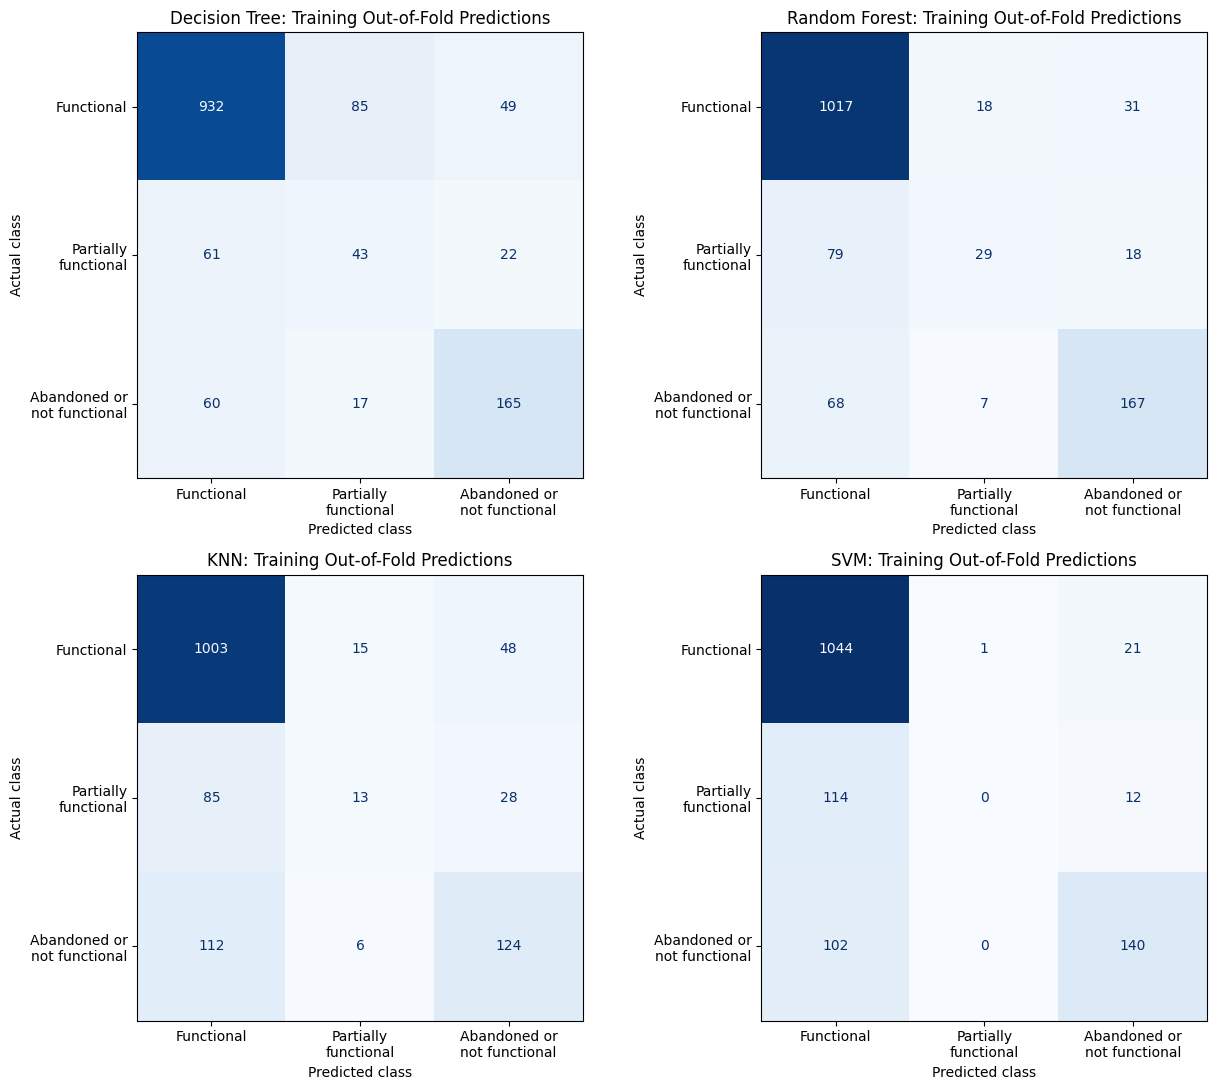

In [44]:
matrices = {name: confusion_matrix(y_development, predictions, labels=CLASS_ORDER)
            for name, predictions in oof_predictions.items()}
max_count = max(matrix.max() for matrix in matrices.values())
plot_labels = ["Functional", "Partially\nfunctional", "Abandoned or\nnot functional"]
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, (name, matrix) in zip(axes.flat, matrices.items()):
    ConfusionMatrixDisplay(matrix, display_labels=plot_labels).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d",
        im_kw={"vmin": 0, "vmax": max_count},
    )
    ax.set_title(f"{name}: Training Out-of-Fold Predictions")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
plt.tight_layout()
plt.show()


In [45]:
confusion_notes = []
for name, cm in matrices.items():
    partial_total, abandoned_total = cm[1].sum(), cm[2].sum()
    partial_to_functional = cm[1, 0]
    abandoned_to_functional = cm[2, 0]
    pred_functional_share = cm[:, 0].sum() / cm.sum()
    partial_recall = cm[1, 1] / partial_total
    abandoned_recall = cm[2, 2] / abandoned_total
    comparison = "higher" if abandoned_recall > partial_recall else "lower or equal"
    confusion_notes.append(
        f"- **{name}:** {partial_to_functional}/{partial_total} Partially functional cases "
        f"({partial_to_functional/partial_total:.1%}) and {abandoned_to_functional}/{abandoned_total} "
        f"Abandoned cases ({abandoned_to_functional/abandoned_total:.1%}) are predicted as Functional. "
        f"Abandoned recall ({abandoned_recall:.3f}) is {comparison} than Partially functional recall "
        f"({partial_recall:.3f}). Functional predictions account for {pred_functional_share:.1%} of rows."
    )
display(Markdown("**Observation:**\n\n" + "\n".join(confusion_notes)))


**Observation:**

- **Decision Tree:** 61/126 Partially functional cases (48.4%) and 60/242 Abandoned cases (24.8%) are predicted as Functional. Abandoned recall (0.682) is higher than Partially functional recall (0.341). Functional predictions account for 73.4% of rows.
- **Random Forest:** 79/126 Partially functional cases (62.7%) and 68/242 Abandoned cases (28.1%) are predicted as Functional. Abandoned recall (0.690) is higher than Partially functional recall (0.230). Functional predictions account for 81.2% of rows.
- **KNN:** 85/126 Partially functional cases (67.5%) and 112/242 Abandoned cases (46.3%) are predicted as Functional. Abandoned recall (0.512) is higher than Partially functional recall (0.103). Functional predictions account for 83.7% of rows.
- **SVM:** 114/126 Partially functional cases (90.5%) and 102/242 Abandoned cases (42.1%) are predicted as Functional. Abandoned recall (0.579) is higher than Partially functional recall (0.000). Functional predictions account for 87.9% of rows.

# 12. Baseline Findings

We summarize the measured ranking, fold variation and class-specific errors. The first two models by baseline mean macro-F1 form a provisional shortlist for deeper investigation. This ordering is descriptive; optimization may change it, and no final model is selected.

In [46]:
shortlist = results.index[:2].tolist()
ranking = "; ".join(f"{name}: {row['Mean CV Macro F1']:.4f} ± {row['Std CV Macro F1']:.4f}"
                    for name, row in results.iterrows())
weak_partial = [name for name in models if reports[name]["Partially functional"]["recall"] < reports[name]["Functional"]["recall"]]
display(Markdown(
    "**Observation:** Mean CV macro-F1 (± fold SD): " + ranking + ".\n\n"
    + "The provisional optimization shortlist is **" + " and ".join(shortlist) + "**. "
    + "This is not a final model choice or evidence of a statistically significant lead.\n\n"
    + ("Partially functional recall is below Functional recall for " + ", ".join(weak_partial)
       + ". These measured gaps justify investigating class weights in the next stage; "
       "they do not prove that weighting or resampling will improve results." if weak_partial else
       "The reports do not show lower Partially functional recall than Functional recall for these baselines.")
))


**Observation:** Mean CV macro-F1 (± fold SD): Random Forest: 0.6542 ± 0.0254; Decision Tree: 0.6289 ± 0.0224; KNN: 0.5365 ± 0.0226; SVM: 0.5239 ± 0.0102.

The provisional optimization shortlist is **Random Forest and Decision Tree**. This is not a final model choice or evidence of a statistically significant lead.

Partially functional recall is below Functional recall for Decision Tree, Random Forest, KNN, SVM. These measured gaps justify investigating class weights in the next stage; they do not prove that weighting or resampling will improve results.

# 13. Next Steps

The next notebook is **`05_model_optimization.ipynb`**. It may tune the shortlisted models, compare class-weight settings where supported, and compare tuned scores against these baselines under fold-safe validation. KNN does not provide `class_weight`; its optimization choices must be handled accordingly.

Feature selection, geographic generalization checks and open preprocessing issues (coordinates, correlated population counts, negative elevations and pending grant/balance fields) remain controlled future experiments. None is changed here. Resampling should be investigated only if justified and must remain inside training folds. Final model selection must precede a single final evaluation on the reserved holdout.

No optimization notebook, model artifact, backend or frontend is created in this stage.

# 14. Final Model Development Summary

The summary below is generated from the executed experiment, so its scores and shortlist remain consistent on rerun. We also recheck source-file hashes to confirm that this notebook did not modify supplied sources or any available preprocessing artifacts.

In [47]:
assert all(file_hash(path) == original for path, original in protected_hashes.items()), "An existing source/artifact changed."
assert set(cv_results) == set(oof_predictions) == set(models)
assert X_development.index.equals(X_train.index)
assert set(X_development.index).isdisjoint(X_test.index)
# Holdout exclusion is enforced by the explicit development-only arguments
# above; a boolean flag alone would not prove absence of leakage.
print("STAGE 6 — BASELINE MODEL DEVELOPMENT SUMMARY")
print("Raw dataset:", df.shape)
print("Training raw predictors:", X_train.shape, "| Reserved raw holdout:", X_test.shape)
print("Reconstructed processed training:", training_reference.shape)
print("Processed features:", len(feature_names))
print("Holdout processed CSV:", saved_test.shape if saved_test is not None else "Absent; expected schema only: " + str((len(y_test), len(feature_names))))
print("Models:", ", ".join(models))
print("Validation: 5-fold StratifiedKFold, shuffle=True, random_state=42; fold-safe preprocessing")
print("Metrics: accuracy, macro precision, macro recall, macro-F1 (primary), weighted F1")
display(results.round(4))
display(minority[["precision", "recall", "f1-score", "support"]].round(4))
print("Highest observed baseline mean macro-F1:", results.index[0], f"{results.iloc[0]['Mean CV Macro F1']:.4f}")
print("Provisional optimization shortlist:", ", ".join(shortlist))
print("Final test labels used for model selection: NO. No candidate predictions or scores on holdout.")
print("Existing supplied sources and available artifacts: hash checks PASS.")
print("Optional audit files present:", ", ".join(existing_artifacts) or "None")
print("Optional audit files missing:", ", ".join(missing_artifacts) or "None")
if missing_artifacts:
    print("Saved contents could not be audited for:", ", ".join(missing_artifacts))
print("Saved preprocessing pipeline verification:", pipeline_verification)
print("requirements.txt:", "Inspected; unchanged" if requirements_text is not None else "Absent in this execution environment")
print("No previous notebook, raw data or preprocessing artifact was written.")


STAGE 6 — BASELINE MODEL DEVELOPMENT SUMMARY
Raw dataset: (1793, 52)
Training raw predictors: (1434, 32) | Reserved raw holdout: (359, 32)
Reconstructed processed training: (1434, 110)
Processed features: 110
Holdout processed CSV: (359, 110)
Models: Decision Tree, Random Forest, KNN, SVM
Validation: 5-fold StratifiedKFold, shuffle=True, random_state=42; fold-safe preprocessing
Metrics: accuracy, macro precision, macro recall, macro-F1 (primary), weighted F1


,Mean CV Accuracy,Std CV Accuracy,Mean CV Macro Precision,Mean CV Macro Recall,Mean CV Macro F1,Std CV Macro F1,Mean CV Weighted F1,Mean Fit Time (s),Mean Score Time (s)
Model,,,,,,,,,
Random Forest,0.8459,0.0060,0.7308,0.6247,0.6542,0.0254,0.8293,0.3752,0.0571
Decision Tree,0.7950,0.0168,0.6276,0.6324,0.6289,0.0224,0.7983,0.1121,0.0458
KNN,0.7950,0.0139,0.6424,0.5190,0.5365,0.0226,0.7670,0.0737,0.0674
SVM,0.8257,0.0076,0.5469,0.5193,0.5239,0.0102,0.7810,0.1342,0.0685


,precision,recall,f1-score,support
Model,,,,
Decision Tree,0.2966,0.3413,0.3173,126.0
Random Forest,0.5370,0.2302,0.3222,126.0
KNN,0.3824,0.1032,0.1625,126.0
SVM,0.0000,0.0000,0.0000,126.0


Highest observed baseline mean macro-F1: Random Forest 0.6542
Provisional optimization shortlist: Random Forest, Decision Tree
Final test labels used for model selection: NO. No candidate predictions or scores on holdout.
Existing supplied sources and available artifacts: hash checks PASS.
Optional audit files present: X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv, feature_names.csv, preprocessing_pipeline.joblib, preprocessing_decisions.md
Optional audit files missing: None
Saved preprocessing pipeline verification: Skipped saved-pipeline verification: artifact sklearn version 1.9.1 differs from runtime 1.8.0. Use one compatible sklearn version across notebook 03, modelling, optimization and eventual backend use. CV continues with the exact reconstructed preprocessing; no artifact was regenerated.
requirements.txt: Inspected; unchanged
No previous notebook, raw data or preprocessing artifact was written.


**Observation:** All four required baselines have visible CV metrics, per-class reports and training out-of-fold confusion matrices. The final holdout was used only for split and distribution verification. The runtime audit and final summary identify optional files that are present, files that are absent, and which saved-content checks were performed. In-memory reconstruction does not constitute verification of absent artifact contents.

**Baseline model development complete. STOPPING HERE. Hyperparameter tuning, class-imbalance optimization, final model selection, and test-set evaluation are intentionally deferred to the next stage.**